In [1]:
import pydicom
import pandas as pd
import matplotlib as plt
import torch
import torchvision
import numpy as np
from pathlib import Path

DATA_ROOT = Path("data/images")
LABEL_FILE = Path("assignment1_labels.csv")
MAPPING_FILE = Path("rsna_to_nih_mapping.csv")

In [2]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
    print(torch.ones(1, device="cuda"))

2.11.0+cu128
12.8
CUDA available: True
NVIDIA RTX 5000 Ada Generation
tensor([1.], device='cuda:0')


In [3]:
labels= pd.read_csv('assignment1_labels.csv')
mapping = pd.read_csv('rsna_to_nih_mapping.csv')
print(labels.shape)
print(mapping.shape)

print(labels.head())

print(mapping.head())

(28989, 9)
(25684, 3)
                                           patientId      x      y  width  \
0  1.2.276.0.7230010.3.1.4.8323329.5872.151787431...    NaN    NaN    NaN   
1  1.2.276.0.7230010.3.1.4.8323329.15466.15178743...    NaN    NaN    NaN   
2  1.2.276.0.7230010.3.1.4.8323329.10973.15178743...  564.0  356.0  274.0   
3  1.2.276.0.7230010.3.1.4.8323329.10973.15178743...  195.0  320.0  281.0   
4  1.2.276.0.7230010.3.1.4.8323329.22658.15178744...    NaN    NaN    NaN   

   height  Target                                   StudyInstanceUID  \
0     NaN       0  1.2.276.0.7230010.3.1.2.8323329.5872.151787431...   
1     NaN       0  1.2.276.0.7230010.3.1.2.8323329.15466.15178743...   
2   496.0       1  1.2.276.0.7230010.3.1.2.8323329.10973.15178743...   
3   515.0       1  1.2.276.0.7230010.3.1.2.8323329.10973.15178743...   
4     NaN       0  1.2.276.0.7230010.3.1.2.8323329.22658.15178744...   

                                   SeriesInstanceUID  \
0  1.2.276.0.7230010.3.1.3

In [4]:
print(labels['StudyInstanceUID'].nunique())

25684


so from that we can understand that labels is 9 columnsut rows which is not similar to the amount of rows in the mapping this suppourts the information that a single patient image can have multiple detections and that labels have the exact amount of uniqueids for patients as the number of rows in the mapping file


In [5]:
df = labels.groupby('patientId')["Target"].max().reset_index()
print(df.shape)
print(df.head())

(25684, 2)
                                           patientId  Target
0  1.2.276.0.7230010.3.1.4.8323329.10001.15178743...       0
1  1.2.276.0.7230010.3.1.4.8323329.10002.15178743...       0
2  1.2.276.0.7230010.3.1.4.8323329.10004.15178743...       0
3  1.2.276.0.7230010.3.1.4.8323329.10005.15178743...       0
4  1.2.276.0.7230010.3.1.4.8323329.10006.15178743...       0


In [6]:
df= df.merge(mapping, how='left', on='patientId')
print(df.shape) 
print(df.head())

(25684, 4)
                                           patientId  Target  nih_patient_id  \
0  1.2.276.0.7230010.3.1.4.8323329.10001.15178743...       0           11683   
1  1.2.276.0.7230010.3.1.4.8323329.10002.15178743...       0            2245   
2  1.2.276.0.7230010.3.1.4.8323329.10004.15178743...       0           30355   
3  1.2.276.0.7230010.3.1.4.8323329.10005.15178743...       0           14758   
4  1.2.276.0.7230010.3.1.4.8323329.10006.15178743...       0            4082   

       nih_image_id  
0  00011683_018.png  
1  00002245_000.png  
2  00030355_000.png  
3  00014758_000.png  
4  00004082_008.png  


In [7]:
print(df['Target'].value_counts(normalize=True))

Target
0    0.779668
1    0.220332
Name: proportion, dtype: float64


In [8]:
from sklearn.model_selection import GroupShuffleSplit

gss= GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
first_idx,second_idx= next(gss.split(df, groups=df['nih_patient_id']))


In [9]:
from sklearn.model_selection import GroupShuffleSplit

gss= GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
first_idx,second_idx= next(gss.split(df, groups=df['nih_patient_id']))

train = df.iloc[first_idx]
temp = df.iloc[second_idx]
print(train.shape)
print(temp.shape)
print(df.shape)
gss= GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx,test_idx= next(gss.split(temp, groups=temp['nih_patient_id']))
val  = temp.iloc[val_idx]
test = temp.iloc[test_idx]
train_patients= set(train['nih_patient_id'])
val_patients= set(val['nih_patient_id'])
test_patients= set(test['nih_patient_id'])


(19124, 4)
(6560, 4)
(25684, 4)


In [10]:
assert len(train_patients & val_patients) == 0
assert len(train_patients & test_patients) == 0
assert len(val_patients & test_patients) == 0

In [11]:
print(train["Target"].value_counts(normalize=True))
print(val["Target"].value_counts(normalize=True))
print(test["Target"].value_counts(normalize=True))


Target
0    0.784825
1    0.215175
Name: proportion, dtype: float64
Target
0    0.751878
1    0.248122
Name: proportion, dtype: float64
Target
0    0.77889
1    0.22111
Name: proportion, dtype: float64


In [12]:
dicom_files = sorted(DATA_ROOT.rglob("*.dcm"))
print("DICOM files found:", len(dicom_files))

for f in dicom_files[:3]:
    print(f.name, "|", f.stem)

print(df["patientId"].head(3).tolist())

DICOM files found: 25684
1.2.276.0.7230010.3.1.4.8323329.10001.1517874346.163716.dcm | 1.2.276.0.7230010.3.1.4.8323329.10001.1517874346.163716
1.2.276.0.7230010.3.1.4.8323329.10002.1517874346.165592.dcm | 1.2.276.0.7230010.3.1.4.8323329.10002.1517874346.165592
1.2.276.0.7230010.3.1.4.8323329.10004.1517874346.174866.dcm | 1.2.276.0.7230010.3.1.4.8323329.10004.1517874346.174866
['1.2.276.0.7230010.3.1.4.8323329.10001.1517874346.163716', '1.2.276.0.7230010.3.1.4.8323329.10002.1517874346.165592', '1.2.276.0.7230010.3.1.4.8323329.10004.1517874346.174866']


In [13]:
# Build a lookup: patientId -> file path
id_to_path = {f.stem: f for f in dicom_files}

# Every file name should be unique
assert len(id_to_path) == len(dicom_files), "Two files share the same name"

# Compare the two sets of IDs
file_ids = set(id_to_path)
exam_ids = set(df["patientId"])
print("Examinations without a file:", len(exam_ids - file_ids))
print("Files without an examination:", len(file_ids - exam_ids))

# Add the path column
df["path"] = df["patientId"].map(id_to_path)
assert df["path"].notna().all(), "Some examinations have no image file"

Examinations without a file: 0
Files without an examination: 0


In [14]:
print(df["path"].head(3).tolist())

[PosixPath('data/images/mdai_public_project_LxR6zdR2_images_2018-08-20-184248/1.2.276.0.7230010.3.1.2.8323329.10001.1517874346.163715/1.2.276.0.7230010.3.1.3.8323329.10001.1517874346.163714/1.2.276.0.7230010.3.1.4.8323329.10001.1517874346.163716.dcm'), PosixPath('data/images/mdai_public_project_LxR6zdR2_images_2018-08-20-184248/1.2.276.0.7230010.3.1.2.8323329.10002.1517874346.165591/1.2.276.0.7230010.3.1.3.8323329.10002.1517874346.165590/1.2.276.0.7230010.3.1.4.8323329.10002.1517874346.165592.dcm'), PosixPath('data/images/mdai_public_project_LxR6zdR2_images_2018-08-20-184248/1.2.276.0.7230010.3.1.2.8323329.10004.1517874346.174865/1.2.276.0.7230010.3.1.3.8323329.10004.1517874346.174864/1.2.276.0.7230010.3.1.4.8323329.10004.1517874346.174866.dcm')]


In [15]:
import pydicom

ds = pydicom.dcmread(df["path"].iloc[0])
print(ds)
print(ds.Rows, ds.Columns)
print(ds.PhotometricInterpretation)
print(ds.ViewPosition)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 202
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Secondary Capture Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.276.0.7230010.3.1.4.8323329.10001.1517874346.163716
(0002,0010) Transfer Syntax UID                 UI: JPEG Baseline (Process 1)
(0002,0012) Implementation Class UID            UI: 1.2.276.0.7230010.3.0.3.6.0
(0002,0013) Implementation Version Name         SH: 'OFFIS_DCMTK_360'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0016) SOP Class UID                       UI: Secondary Capture Image Storage
(0008,0018) SOP Instance UID                    UI: 1.2.276.0.7230010.3.1.4.8323329.10001.1517874346.163716
(0008,0020) Study Date                          DA: '19010101'
(0008,0030) Study Time                  

In [16]:
img = ds.pixel_array
print(img.shape, img.dtype, img.min(), img.max())

(1024, 1024) uint8 0 255


In [17]:
records = []
for pid, path in zip(df["patientId"], df["path"]):
    ds = pydicom.dcmread(path, stop_before_pixels=True)
    records.append({
        "patientId": pid,
        "rows": ds.Rows,
        "cols": ds.Columns,
        "photometric": ds.PhotometricInterpretation,
        "view": ds.ViewPosition,
        "sex": ds.PatientSex,
        "age": ds.PatientAge,
    })

meta = pd.DataFrame(records)
for col in ["rows", "cols", "photometric", "view", "sex"]:
    print(meta[col].value_counts())


rows
1024    25684
Name: count, dtype: int64
cols
1024    25684
Name: count, dtype: int64
photometric
MONOCHROME2    25684
Name: count, dtype: int64
view
PA    13979
AP    11705
Name: count, dtype: int64
sex
M    14593
F    11091
Name: count, dtype: int64


In [18]:
n = len(df)
df = df.merge(meta, on="patientId", how="left")
assert len(df) == n
assert df["view"].notna().all()

In [19]:
print(df.groupby("view")["Target"].mean())

view
AP    0.375481
PA    0.090421
Name: Target, dtype: float64


In [20]:
from sklearn.model_selection import GroupShuffleSplit

gss= GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
first_idx,second_idx= next(gss.split(df, groups=df['nih_patient_id']))

train = df.iloc[first_idx]
temp = df.iloc[second_idx]
print(train.shape)
print(temp.shape)
print(df.shape)
gss= GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx,test_idx= next(gss.split(temp, groups=temp['nih_patient_id']))
val  = temp.iloc[val_idx]
test = temp.iloc[test_idx]
train_patients= set(train['nih_patient_id'])
val_patients= set(val['nih_patient_id'])
test_patients= set(test['nih_patient_id'])


(19124, 11)
(6560, 11)
(25684, 11)


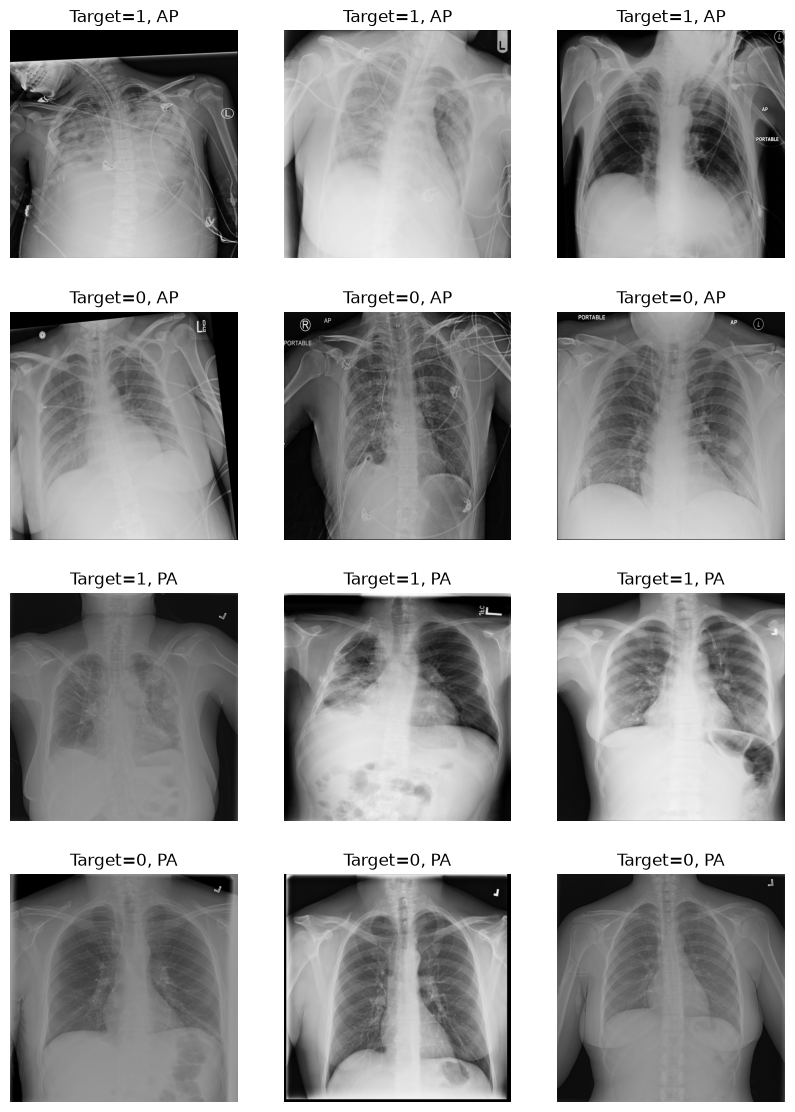

In [21]:
import matplotlib.pyplot as plt
parts = []
for view in ["AP", "PA"]:
    for t in [1, 0]:
        group = train[(train["view"] == view) & (train["Target"] == t)]
        parts.append(group.sample(3, random_state=0))
examples = pd.concat(parts)

fig, axes = plt.subplots(4, 3, figsize=(10, 14))
for ax, (_, row) in zip(axes.flat, examples.iterrows()):
    img = pydicom.dcmread(row["path"]).pixel_array
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Target={row['Target']}, {row['view']}")
    ax.axis("off")
plt.show()

1.2.276.0.7230010.3.1.4.8323329.28028.1517874482.812128


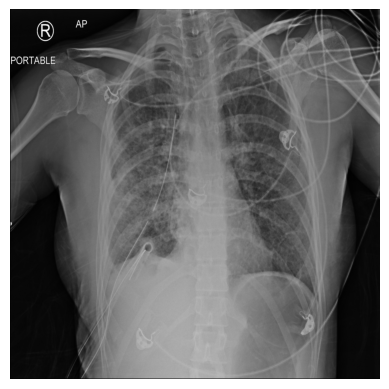

In [22]:
row = examples.iloc[4]
print(row["patientId"])
plt.imshow(pydicom.dcmread(row["path"]).pixel_array, cmap="gray")
plt.axis("off")
plt.show()

In [23]:
print(row)

patientId         1.2.276.0.7230010.3.1.4.8323329.28028.15178744...
Target                                                            0
nih_patient_id                                                27093
nih_image_id                                       00027093_002.png
path              data/images/mdai_public_project_LxR6zdR2_image...
rows                                                           1024
cols                                                           1024
photometric                                             MONOCHROME2
view                                                             AP
sex                                                               F
age                                                              30
Name: 16568, dtype: object


In [24]:
import numpy as np
import torch
from PIL import Image

def load_image(path, size=224):
    img = pydicom.dcmread(path).pixel_array
    img = Image.fromarray(img).resize((size, size))
    img = np.array(img, dtype=np.float32) / 255.0
    return torch.from_numpy(img).unsqueeze(0)

x = load_image(train["path"].iloc[0])
print(x.shape, x.dtype, x.min(), x.max())

torch.Size([1, 224, 224]) torch.float32 tensor(0.) tensor(0.8784)


In [25]:

from torch.utils.data import Dataset
import torchvision.transforms as T

train_tf = T.Compose([
    T.RandomAffine(degrees=7, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    T.ColorJitter(brightness=0.1, contrast=0.1),
])
class CRDataset(Dataset):
    def __init__(self, table, transform=None):
        self.table = table
        self.transform = transform

    def __len__(self):
        return len(self.table)

    def __getitem__(self, i):
        row = self.table.iloc[i]
        x = load_image(row["path"])
        if self.transform:
            x = self.transform(x)
        y = torch.tensor(row["Target"], dtype=torch.float32)
        return x, y

In [26]:
ds = CRDataset(train)
ds = CRDataset(test)
ds = CRDataset(eval)

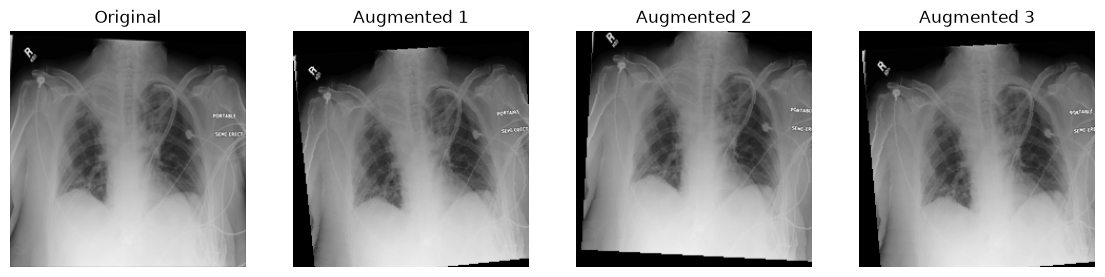

In [27]:
plain = CRDataset(train)
aug = CRDataset(train, train_tf)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(plain[0][0][0], cmap="gray")
axes[0].set_title("Original")
for k in range(1, 4):
    axes[k].imshow(aug[0][0][0], cmap="gray")
    axes[k].set_title(f"Augmented {k}")
for ax in axes:
    ax.axis("off")
plt.show()

In [28]:
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix

for name, split in [("val", val), ("test", test)]:
    y_true = split["Target"]
    y_pred = [0] * len(split)
    print(name, "accuracy:", accuracy_score(y_true, y_pred),
          "sensitivity:", recall_score(y_true, y_pred))

val accuracy: 0.7518775274407856 sensitivity: 0.0
test accuracy: 0.7788896061975468 sensitivity: 0.0


In [29]:
confusion_matrix(y_true, y_pred)

array([[2413,    0],
       [ 685,    0]])

In [30]:
def extract_xray_features(image):
    pixels = image.flatten()

    mean = pixels.mean()
    std = pixels.std()
    p10, p50, p90 = np.percentile(pixels, [10, 50, 90])


    features = np.array([mean, std, p10, p50, p90], dtype=np.float32)
    return features

In [31]:
print(extract_xray_features(load_image(train["path"].iloc[0])))

[0.4236032  0.2170617  0.04313726 0.43529412 0.7254902 ]


In [32]:
X_train = np.array([
    extract_xray_features(load_image(path))
    for path in train["path"]
])

y_train = train["Target"].to_numpy()
X_test = np.array([
    extract_xray_features(load_image(path))
    for path in test["path"]
])
y_test = test["Target"].to_numpy()
X_val = np.array([
    extract_xray_features(load_image(path))
    for path in val["path"]
])
y_val = val["Target"].to_numpy()


In [33]:
np.save("data/X_train.npy", X_train)
np.save("data/X_val.npy", X_val)
np.save("data/X_test.npy", X_test)
np.save("data/y_train.npy", y_train)
np.save("data/y_val.npy", y_val)
np.save("data/y_test.npy", y_test)

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [35]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
).reshape(-1, 1)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.float32
).reshape(-1, 1)

In [36]:
positive_weight = (y_train == 0).sum() / (y_train == 1).sum()

positive_weight = torch.tensor(
    positive_weight,
    dtype=torch.float32
)

In [37]:
import random


seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [38]:
model = nn.Linear(5, 1)

In [39]:
loss_function = nn.BCEWithLogitsLoss(
    pos_weight=positive_weight
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [40]:
loss_function = nn.BCEWithLogitsLoss(
    pos_weight=positive_weight
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)
for epoch in range(1000):

    optimizer.zero_grad()

    logits = model(X_train_tensor)

    loss = loss_function(
        logits,
        y_train_tensor
    )

    loss.backward()

    optimizer.step()

    if epoch % 100 == 0:
        print(epoch, loss.item())

0 1.2393907308578491
100 1.1519973278045654
200 1.1039928197860718
300 1.0793521404266357
400 1.0681357383728027
500 1.063496470451355
600 1.0615675449371338
700 1.0605902671813965
800 1.059899926185608
900 1.0592844486236572


In [41]:
with torch.no_grad():
    val_logits = model(X_val_tensor)
    val_probabilities = torch.sigmoid(val_logits)

    val_predictions = (
        val_probabilities >= 0.5
    ).int()

In [42]:
from sklearn.metrics import precision_score
print("Validation accuracy:",
      accuracy_score(y_val, val_predictions))

print("Validation sensitivity/recall:",
      recall_score(y_val, val_predictions))

print("Validation precision:",
      precision_score(y_val, val_predictions))

print("Validation confusion matrix:")
print(confusion_matrix(y_val, val_predictions))

Validation accuracy: 0.6629116117850953
Validation sensitivity/recall: 0.6379511059371362
Validation precision: 0.3903133903133903
Validation confusion matrix:
[[1747  856]
 [ 311  548]]


In [43]:
loss_function = nn.BCEWithLogitsLoss(
    pos_weight=positive_weight
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)
for epoch in range(10000):

    optimizer.zero_grad()

    logits = model(X_train_tensor)

    loss = loss_function(
        logits,
        y_train_tensor
    )

    loss.backward()

    optimizer.step()

    if epoch % 100 == 0:
        print(epoch, loss.item())

0 1.0586870908737183
100 1.0553439855575562
200 1.0525585412979126
300 1.05024254322052
400 1.0483245849609375
500 1.046740174293518
600 1.0454293489456177
700 1.0443378686904907
800 1.0434184074401855
900 1.0426305532455444
1000 1.0419410467147827
1100 1.0413236618041992
1200 1.0407588481903076
1300 1.0402331352233887
1400 1.039737582206726
1500 1.039266586303711
1600 1.038817048072815
1700 1.038387417793274
1800 1.0379767417907715
1900 1.0375850200653076
2000 1.0372116565704346
2100 1.0368571281433105
2200 1.0365208387374878
2300 1.0362027883529663
2400 1.035902738571167
2500 1.035620093345642
2600 1.035354733467102
2700 1.0351059436798096
2800 1.034873604774475
2900 1.0346568822860718
3000 1.034455418586731
3100 1.0342684984207153
3200 1.0340958833694458
3300 1.0339365005493164
3400 1.033790111541748
3500 1.0336562395095825
3600 1.0335339307785034
3700 1.033422827720642
3800 1.0333219766616821
3900 1.0332311391830444
4000 1.0331496000289917
4100 1.0330767631530762
4200 1.03301203250

In [44]:
print("Validation accuracy:",
      accuracy_score(y_val, val_predictions))

print("Validation sensitivity/recall:",
      recall_score(y_val, val_predictions))

print("Validation precision:",
      precision_score(y_val, val_predictions))

print("Validation confusion matrix:")
print(confusion_matrix(y_val, val_predictions))

Validation accuracy: 0.6629116117850953
Validation sensitivity/recall: 0.6379511059371362
Validation precision: 0.3903133903133903
Validation confusion matrix:
[[1747  856]
 [ 311  548]]


In [45]:
from sklearn.metrics import roc_auc_score

val_auc = roc_auc_score(
    y_val,
    val_probabilities.detach().numpy().ravel()
)

print("Weighted validation AUC:", val_auc)

Weighted validation AUC: 0.672404948709222


In [46]:
from sklearn.metrics import recall_score, confusion_matrix, roc_auc_score

unweighted_model = nn.Linear(5, 1)
unweighted_loss = nn.BCEWithLogitsLoss()
unweighted_optimizer = torch.optim.Adam(
    unweighted_model.parameters(),
    lr=0.001
)

for epoch in range(1000):
    unweighted_optimizer.zero_grad()
    logits = unweighted_model(X_train_tensor)
    loss = unweighted_loss(logits, y_train_tensor)
    loss.backward()
    unweighted_optimizer.step()

with torch.no_grad():
    p_weighted = torch.sigmoid(model(X_val_tensor)).numpy().ravel()
    p_unweighted = torch.sigmoid(
        unweighted_model(X_val_tensor)
    ).numpy().ravel()

for name, p in [
    ("weighted", p_weighted),
    ("unweighted", p_unweighted)
]:
    pred = (p >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        y_val, pred
    ).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    auc = roc_auc_score(y_val, p)

    print(
        name,
        "sensitivity:", sensitivity,
        "specificity:", specificity,
        "AUC:", auc
    )

weighted sensitivity: 0.6903376018626309 specificity: 0.6219746446407991 AUC: 0.6831720540953686
unweighted sensitivity: 0.0 specificity: 1.0 AUC: 0.6640184581505088


In [47]:
final_model = model
final_name = "weighted"

print("Final model:", final_name)

Final model: weighted


In [48]:

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)
with torch.no_grad():
    test_probabilities = torch.sigmoid(
        final_model(X_test_tensor)
    ).numpy().ravel()

test_predictions = (
    test_probabilities >= 0.5
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_predictions
).ravel()

print("Final model:", final_name)
print("Sensitivity:", tp / (tp + fn))
print("Specificity:", tn / (tn + fp))
print("AUC:", roc_auc_score(y_test, test_probabilities))

Final model: weighted
Sensitivity: 0.6175182481751825
Specificity: 0.6319933692498964
AUC: 0.6526718111446213


In [49]:
from sklearn.metrics import f1_score
for name, p in [
    ("weighted", p_weighted),
    ("unweighted", p_unweighted)
]:
    pred = (p >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val, pred
    ).ravel()

    print("\n", name)
    print("Sensitivity:", tp / (tp + fn))
    print("Specificity:", tn / (tn + fp))
    print("Precision:", precision_score(y_val, pred))
    print("Accuracy:", accuracy_score(y_val, pred))
    print("F1:", f1_score(y_val, pred))
    print("AUC:", roc_auc_score(y_val, p))
    print("Confusion matrix:")
    print(confusion_matrix(y_val, pred))


 weighted
Sensitivity: 0.6903376018626309
Specificity: 0.6219746446407991
Precision: 0.3760304375396322
Accuracy: 0.6389370306181398
F1: 0.48686371100164205
AUC: 0.6831720540953686
Confusion matrix:
[[1619  984]
 [ 266  593]]

 unweighted
Sensitivity: 0.0
Specificity: 1.0
Precision: 0.0
Accuracy: 0.7518775274407856
F1: 0.0
AUC: 0.6640184581505088
Confusion matrix:
[[2603    0]
 [ 859    0]]


/home/mohamed.farrag/medimaging-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [50]:
test_predictions = (
    test_probabilities >= 0.5
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_predictions
).ravel()

print("Final model:", final_name)
print("Sensitivity:", tp / (tp + fn))
print("Specificity:", tn / (tn + fp))
print("Precision:", precision_score(y_test, test_predictions))
print("Accuracy:", accuracy_score(y_test, test_predictions))
print("F1:", f1_score(y_test, test_predictions))
print("AUC:", roc_auc_score(y_test, test_probabilities))
print("Confusion matrix:")
print(confusion_matrix(y_test, test_predictions))

Final model: weighted
Sensitivity: 0.6175182481751825
Specificity: 0.6319933692498964
Precision: 0.32265446224256294
Accuracy: 0.6287927695287282
F1: 0.42384769539078154
AUC: 0.6526718111446213
Confusion matrix:
[[1525  888]
 [ 262  423]]


In [51]:
images_train = np.zeros(
    (len(train), 224, 224),
    dtype=np.uint8
)

for i, path in enumerate(train["path"]):
    image = pydicom.dcmread(path).pixel_array
    image = Image.fromarray(image).resize((224, 224))
    images_train[i] = np.array(image, dtype=np.uint8)

np.save("data/images_train.npy", images_train)

In [52]:
images_val = np.zeros((len(val), 224, 224), dtype=np.uint8)

for i, path in enumerate(val["path"]):
    image = pydicom.dcmread(path).pixel_array
    image = Image.fromarray(image).resize((224, 224))
    images_val[i] = np.array(image, dtype=np.uint8)

np.save("data/images_val.npy", images_val)

In [53]:
images_test = np.zeros((len(test), 224, 224), dtype=np.uint8)

for i, path in enumerate(test["path"]):
    image = pydicom.dcmread(path).pixel_array
    image = Image.fromarray(image).resize((224, 224))
    images_test[i] = np.array(image, dtype=np.uint8)

np.save("data/images_test.npy", images_test)

In [54]:
original = load_image(train["path"].iloc[0])[0].numpy()
cached = images_train[0].astype(np.float32) / 255

print(np.abs(original - cached).max())
assert np.allclose(original, cached)

0.0


In [55]:
import random
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as T

from pathlib import Path
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

Path("outputs").mkdir(exist_ok=True)
print(device)

cuda


In [56]:
images_train = np.load("data/images_train.npy")
images_val = np.load("data/images_val.npy")
images_test = np.load("data/images_test.npy")

y_train = np.load("data/y_train.npy")
y_val = np.load("data/y_val.npy")
y_test = np.load("data/y_test.npy")

assert len(images_train) == len(y_train)
assert len(images_val) == len(y_val)
assert len(images_test) == len(y_test)

In [57]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

In [58]:
scaler = StandardScaler()

X_train = scaler.fit_transform(np.load("data/X_train.npy"))
X_val = scaler.transform(np.load("data/X_val.npy"))

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

positive_weight = torch.tensor(
    (y_train == 0).sum() / (y_train == 1).sum(),
    dtype=torch.float32
)

In [59]:
baseline_results = []

for name in ["unweighted", "weighted"]:
    set_seed(42)
    baseline = nn.Linear(5, 1)

    weight = positive_weight if name == "weighted" else None
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=weight)
    optimizer = torch.optim.Adam(baseline.parameters(), lr=0.001)

    for epoch in range(10000):
        optimizer.zero_grad()
        loss = loss_fn(baseline(X_train_tensor), y_train_tensor)
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        probabilities = torch.sigmoid(baseline(X_val_tensor)).numpy().ravel()

    predictions = probabilities >= 0.5
    tn, fp, fn, tp = confusion_matrix(
        y_val, predictions, labels=[0, 1]
    ).ravel()

    baseline_results.append({
        "model": name,
        "sensitivity": tp / (tp + fn),
        "specificity": tn / (tn + fp),
        "auc": roc_auc_score(y_val, probabilities)
    })

    torch.save(baseline.state_dict(), f"outputs/baseline_{name}.pt")
    np.save(f"outputs/baseline_{name}_val.npy", probabilities)

baseline_results = pd.DataFrame(baseline_results)
baseline_results.to_csv("outputs/baseline_validation.csv", index=False)
print(baseline_results)

        model  sensitivity  specificity       auc
0  unweighted     0.008149     0.994622  0.682956
1    weighted     0.686845     0.621590  0.683356


In [60]:
class CachedDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        x = torch.from_numpy(self.images[i]).float() / 255
        x = x.unsqueeze(0)

        if self.transform is not None:
            x = self.transform(x)

        y = torch.tensor(self.labels[i], dtype=torch.float32)
        return x, y

In [61]:
train_tf = T.Compose([
    T.RandomAffine(
        degrees=7,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    T.ColorJitter(brightness=0.1, contrast=0.1)
])

train_dataset = CachedDataset(images_train, y_train, train_tf)
val_dataset = CachedDataset(images_val, y_val)
test_dataset = CachedDataset(images_test, y_test)

In [62]:
def make_train_loader(seed):
    generator = torch.Generator().manual_seed(seed)

    return DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True,
        generator=generator
    )

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

train_loader = make_train_loader(42)

x, y = next(iter(train_loader))
print(x.shape, y.shape)

torch.Size([32, 1, 224, 224]) torch.Size([32])


In [63]:
def make_model():
    model = resnet18(weights=ResNet18_Weights.DEFAULT)

    old_weights = model.conv1.weight.detach()

    model.conv1 = nn.Conv2d(
        1, 64, kernel_size=7, stride=2, padding=3, bias=False
    )

    with torch.no_grad():
        model.conv1.weight.copy_(
            old_weights.sum(dim=1, keepdim=True)
        )

    model.fc = nn.Linear(model.fc.in_features, 1)

    return model.to(device)

In [64]:
loss_fn = nn.BCEWithLogitsLoss(
    pos_weight=positive_weight.to(device)
)

In [65]:
def train_one_epoch(model, loader, optimizer):
    model.eval()
    model.fc.train()

    if next(model.layer4.parameters()).requires_grad:
        model.layer4.train()

    total_loss = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).unsqueeze(1)

        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(x)

    return total_loss / len(loader.dataset)

In [66]:
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    probabilities = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).unsqueeze(1)

            logits = model(x)
            total_loss += loss_fn(logits, y).item() * len(x)

            probabilities.append(
                torch.sigmoid(logits).cpu().numpy().ravel()
            )

    return (
        total_loss / len(loader.dataset),
        np.concatenate(probabilities)
    )

In [67]:
set_seed(42)
model = make_model()

for p in model.parameters():
    p.requires_grad = False

for p in model.fc.parameters():
    p.requires_grad = True

model.eval()
with torch.no_grad():
    print(model(x.to(device)).shape)

small_loader = DataLoader(
    Subset(train_dataset, range(min(2000, len(train_dataset)))),
    batch_size=32
)

optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

start = time.perf_counter()
train_one_epoch(model, small_loader, optimizer)
seconds = time.perf_counter() - start

print("Subset seconds:", round(seconds))
print(
    "Approximate full Stage 1 epoch minutes:",
    round(seconds * len(train_dataset) / len(small_loader.dataset) / 60, 1)
)

del optimizer, model

torch.Size([32, 1])
Subset seconds: 2
Approximate full Stage 1 epoch minutes: 0.4


In [68]:
def train_stage(model, loader, optimizer, epochs, name):
    history = []
    best_auc = -1
    best_path = f"outputs/{name}_best.pt"

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, loader, optimizer)
        val_loss, val_probs = evaluate(model, val_loader)
        val_auc = roc_auc_score(y_val, val_probs)

        history.append([epoch + 1, train_loss, val_loss, val_auc])

        pd.DataFrame(
            history,
            columns=["epoch", "train_loss", "val_loss", "val_auc"]
        ).to_csv(f"outputs/{name}_history.csv", index=False)

        torch.save(model.state_dict(), f"outputs/{name}_last.pt")

        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(model.state_dict(), best_path)
            np.save(f"outputs/{name}_val.npy", val_probs)

        print(name, epoch + 1, train_loss, val_loss, val_auc, flush=True)

    model.load_state_dict(
        torch.load(best_path, map_location=device, weights_only=True)
    )

    _, test_probs = evaluate(model, test_loader)
    np.save(f"outputs/{name}_test.npy", test_probs)

    return best_auc

In [69]:
results = []

for seed in [42, 43, 44]:
    set_seed(seed)
    model = make_model()
    train_loader = make_train_loader(seed)

    # Stage 1: only the head is trainable
    for p in model.parameters():
        p.requires_grad = False

    for p in model.fc.parameters():
        p.requires_grad = True

    optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

    stage1_auc = train_stage(
        model, train_loader, optimizer,
        epochs=5, name=f"seed{seed}_stage1"
    )

    # Stage 2: continue from the selected Stage 1 checkpoint
    for p in model.layer4.parameters():
        p.requires_grad = True

    optimizer = torch.optim.Adam(
        list(model.layer4.parameters()) + list(model.fc.parameters()),
        lr=0.0001
    )

    stage2_auc = train_stage(
        model, train_loader, optimizer,
        epochs=5, name=f"seed{seed}_stage2"
    )

    results.append([seed, stage1_auc, stage2_auc])

    pd.DataFrame(
        results,
        columns=["seed", "stage1_auc", "stage2_auc"]
    ).to_csv("outputs/validation_results.csv", index=False)

    del optimizer, model

seed42_stage1 1 0.8739997225684417 0.8391925287618588 0.8303260722270399
seed42_stage1 2 0.8301077375125745 0.8449829008660518 0.8345998192289099
seed42_stage1 3 0.8175971747142853 0.8403394923500764 0.8379361683952921
seed42_stage1 4 0.8131213624765125 0.8129174764758241 0.8402170505331673
seed42_stage1 5 0.8121040322445995 0.812698686281289 0.8410828912819764
seed42_stage2 1 0.8385363143748555 0.8392545436586968 0.8570499607106871
seed42_stage2 2 0.7373826761196857 0.7651187397371751 0.8655281337867071
seed42_stage2 3 0.7007328359259394 0.7598051084114044 0.8665979122325498
seed42_stage2 4 0.6701305988966434 0.7640100505433284 0.8661287660830144
seed42_stage2 5 0.6351478096207573 0.8484283290213757 0.8558133648065254
seed43_stage1 1 0.8789868782664213 0.8541089592125979 0.8240684049970102
seed43_stage1 2 0.8316908381619081 0.849604597228032 0.8331981947935956
seed43_stage1 3 0.8217746680238162 0.8187832134194212 0.83730601880073
seed43_stage1 4 0.8140823017526087 0.8143442150383998 0

In [70]:
results = pd.read_csv("outputs/validation_results.csv")
print(results)

mean_auc = results[["stage1_auc", "stage2_auc"]].mean()
print("Mean validation AUC:")
print(mean_auc)

final_stage = 1 if mean_auc["stage1_auc"] >= mean_auc["stage2_auc"] else 2

print("Selected stage:", final_stage)
Path("outputs/selected_stage.txt").write_text(str(final_stage))

   seed  stage1_auc  stage2_auc
0    42    0.841083    0.866598
1    43    0.840988    0.866100
2    44    0.840303    0.869297
Mean validation AUC:
stage1_auc    0.840791
stage2_auc    0.867332
dtype: float64
Selected stage: 2


1

In [71]:
import sys

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("PyTorch CUDA build:", torch.version.cuda)

Python: /home/mohamed.farrag/medimaging-env/bin/python
PyTorch: 2.11.0+cu128
PyTorch CUDA build: 12.8


In [72]:
baseline_X_test = scaler.transform(np.load("data/X_test.npy"))

baseline_X_test = torch.tensor(
    baseline_X_test, dtype=torch.float32
)

baseline_y_test = np.load("data/y_test.npy")

In [73]:
baseline_model = nn.Linear(5, 1)

baseline_model.load_state_dict(
    torch.load(
        "outputs/baseline_weighted.pt",
        map_location="cpu",
        weights_only=True
    )
)

baseline_model.eval()

Linear(in_features=5, out_features=1, bias=True)

In [74]:
with torch.no_grad():
    baseline_test_probs = torch.sigmoid(
        baseline_model(baseline_X_test)
    ).numpy().ravel()

baseline_test_pred = baseline_test_probs >= 0.5

np.save("outputs/baseline_weighted_test.npy", baseline_test_probs)

In [75]:


cm = confusion_matrix(
    baseline_y_test, baseline_test_pred, labels=[0, 1]
)
tn, fp, fn, tp = cm.ravel()

metrics = {
    "sensitivity": tp / (tp + fn),
    "specificity": tn / (tn + fp),
    "precision": precision_score(
        baseline_y_test, baseline_test_pred, zero_division=0
    ),
    "accuracy": accuracy_score(baseline_y_test, baseline_test_pred),
    "F1": f1_score(baseline_y_test, baseline_test_pred, zero_division=0),
    "AUC": roc_auc_score(baseline_y_test, baseline_test_probs)
}

print(pd.Series(metrics))
print("Confusion matrix:")
print(cm)

pd.DataFrame([metrics]).to_csv(
    "outputs/baseline_weighted_test_metrics.csv", index=False
)
np.save("outputs/baseline_weighted_test_confusion.npy", cm)

sensitivity    0.617518
specificity    0.632408
precision      0.322901
accuracy       0.629116
F1             0.424060
AUC            0.652842
dtype: float64
Confusion matrix:
[[1526  887]
 [ 262  423]]


In [76]:


y_test = np.load("data/y_test.npy")
results = []

for seed in [42, 43, 44]:
    probs = np.load(f"outputs/seed{seed}_stage2_test.npy").ravel()
    pred = probs >= 0.5

    cm = confusion_matrix(y_test, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    results.append({
        "seed": seed,
        "sensitivity": tp / (tp + fn),
        "specificity": tn / (tn + fp),
        "precision": precision_score(y_test, pred, zero_division=0),
        "accuracy": accuracy_score(y_test, pred),
        "F1": f1_score(y_test, pred, zero_division=0),
        "AUC": roc_auc_score(y_test, probs)
    })

    print(f"\nSeed {seed} confusion matrix:")
    print(cm)
    np.save(f"outputs/seed{seed}_stage2_confusion.npy", cm)

results = pd.DataFrame(results).set_index("seed")
summary = results.agg(["mean", "std"]).T

print("\nResults per seed:")
print(results.round(4))

print("\nMean and standard deviation:")
print(summary.round(4))

results.to_csv("outputs/cnn_test_per_seed.csv")
summary.to_csv("outputs/cnn_test_summary.csv")


Seed 42 confusion matrix:
[[1913  500]
 [ 144  541]]

Seed 43 confusion matrix:
[[1933  480]
 [ 154  531]]

Seed 44 confusion matrix:
[[2063  350]
 [ 217  468]]

Results per seed:
      sensitivity  specificity  precision  accuracy      F1     AUC
seed                                                               
42         0.7898       0.7928     0.5197    0.7921  0.6269  0.8669
43         0.7752       0.8011     0.5252    0.7954  0.6262  0.8690
44         0.6832       0.8550     0.5721    0.8170  0.6228  0.8729

Mean and standard deviation:
               mean     std
sensitivity  0.7494  0.0578
specificity  0.8163  0.0338
precision    0.5390  0.0288
accuracy     0.8015  0.0135
F1           0.6253  0.0022
AUC          0.8696  0.0030


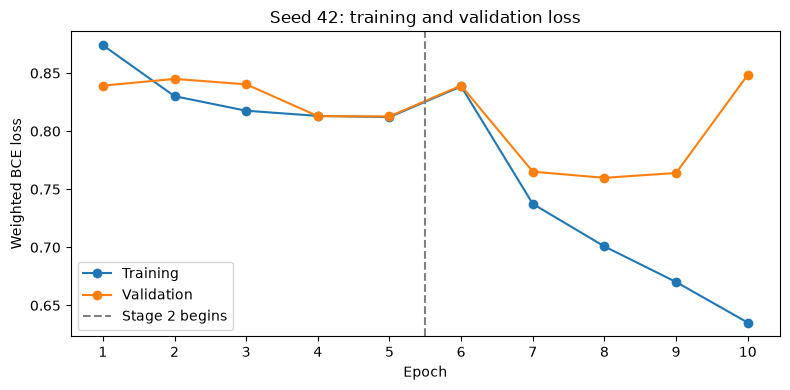

In [77]:


stage1 = pd.read_csv("outputs/seed42_stage1_history.csv")
stage2 = pd.read_csv("outputs/seed42_stage2_history.csv")

history = pd.concat([stage1, stage2], ignore_index=True)
epochs = range(1, len(history) + 1)

plt.figure(figsize=(8, 4))

plt.plot(epochs, history["train_loss"], marker="o", label="Training")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation")

plt.axvline(
    len(stage1) + 0.5,
    color="gray",
    linestyle="--",
    label="Stage 2 begins"
)

plt.xlabel("Epoch")
plt.ylabel("Weighted BCE loss")
plt.title("Seed 42: training and validation loss")
plt.xticks(epochs)
plt.legend()
plt.tight_layout()

plt.savefig("outputs/seed42_loss_curves.png", dpi=300)
plt.show()

In [78]:

from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)
y_test = np.load("data/y_test.npy")

models = {
    "Trivial baseline": np.zeros(len(y_test)),
    "Simple baseline": np.load("outputs/baseline_weighted_test.npy").ravel(),
    "CNN (seed 42)": np.load("outputs/seed42_stage2_test.npy").ravel()
}

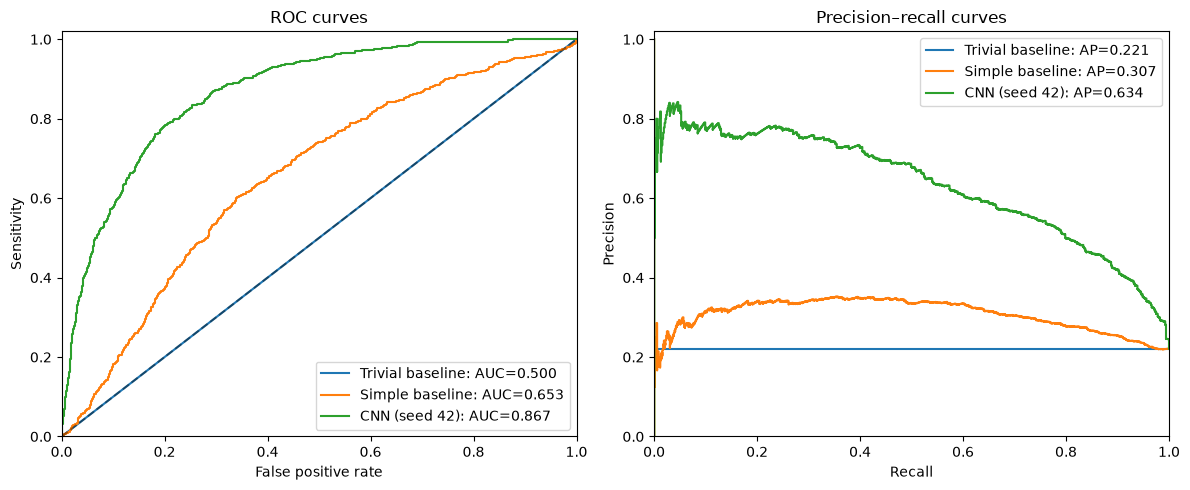

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, probs in models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)

    axes[0].plot(fpr, tpr, label=f"{name}: AUC={auc:.3f}")

    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)

    axes[1].step(
        recall, precision, where="post",
        label=f"{name}: AP={ap:.3f}"
    )

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set(xlabel="False positive rate", ylabel="Sensitivity", title="ROC curves")

axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision–recall curves")

for ax in axes:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.legend()

plt.tight_layout()
plt.savefig("outputs/test_roc_pr_curves.png", dpi=300)
plt.show()

In [80]:
y_val = np.load("data/y_val.npy")
val_probs = np.load("outputs/seed42_stage2_val.npy").ravel()

fpr, tpr, thresholds = roc_curve(
    y_val, val_probs, drop_intermediate=False
)

chosen_thresholds = {
    "Screening": thresholds[tpr >= 0.90].max(),
    "High specificity": thresholds[(1 - fpr) >= 0.90].min()
}

print(chosen_thresholds)

pd.Series(chosen_thresholds, name="threshold").to_csv(
    "outputs/seed42_thresholds.csv"
)

{'Screening': np.float64(0.34259164333343506), 'High specificity': np.float64(0.7640824317932129)}


In [81]:
y_test = np.load("data/y_test.npy")
test_probs = np.load("outputs/seed42_stage2_test.npy").ravel()

results = []

for name, threshold in chosen_thresholds.items():
    predictions = test_probs >= threshold

    cm = confusion_matrix(y_test, predictions, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    results.append({
        "setting": name,
        "threshold": threshold,
        "sensitivity": tp / (tp + fn),
        "specificity": tn / (tn + fp),
        "precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

    print(f"\n{name} confusion matrix:")
    print(cm)

results = pd.DataFrame(results)
print(results.round(4))

results.to_csv("outputs/seed42_threshold_test_results.csv", index=False)


Screening confusion matrix:
[[1696  717]
 [  89  596]]

High specificity confusion matrix:
[[2204  209]
 [ 314  371]]
            setting  threshold  sensitivity  specificity  precision    TN  \
0         Screening     0.3426       0.8701       0.7029     0.4539  1696   
1  High specificity     0.7641       0.5416       0.9134     0.6397  2204   

    FP   FN   TP  
0  717   89  596  
1  209  314  371  


In [82]:
y_test = np.load("data/y_test.npy")
test_probs = np.load("outputs/seed42_stage2_test.npy").ravel()
from sklearn.calibration import calibration_curve

fraction_positive, mean_probability = calibration_curve(
    y_test,
    test_probs,
    n_bins=10,
    strategy="uniform"
)

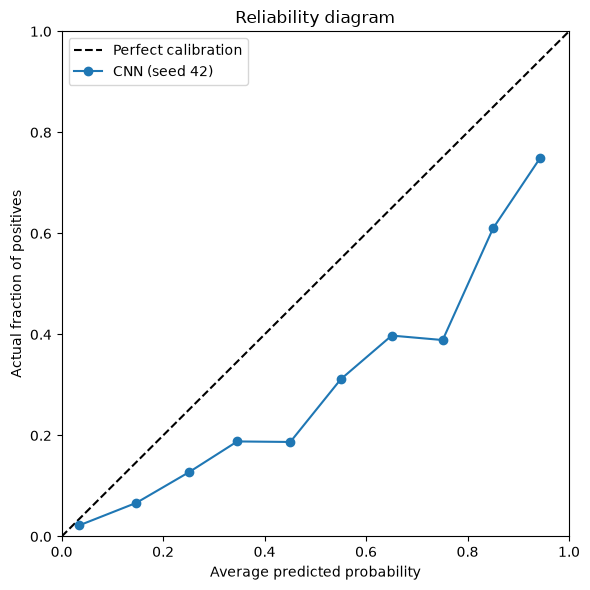

In [83]:
plt.figure(figsize=(6, 6))

plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.plot(
    mean_probability,
    fraction_positive,
    marker="o",
    label="CNN (seed 42)"
)

plt.xlabel("Average predicted probability")
plt.ylabel("Actual fraction of positives")
plt.title("Reliability diagram")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

plt.savefig("outputs/seed42_reliability.png", dpi=300)
plt.show()

In [84]:
images_test = np.load("data/images_test.npy", mmap_mode="r")
y_test = np.load("data/y_test.npy")
test_probs = np.load("outputs/seed42_stage2_test.npy").ravel()

threshold = 0.5
test_pred = test_probs >= threshold

assert len(test) == len(images_test) == len(test_probs) == len(y_test)
assert np.array_equal(test["Target"].to_numpy(), y_test)

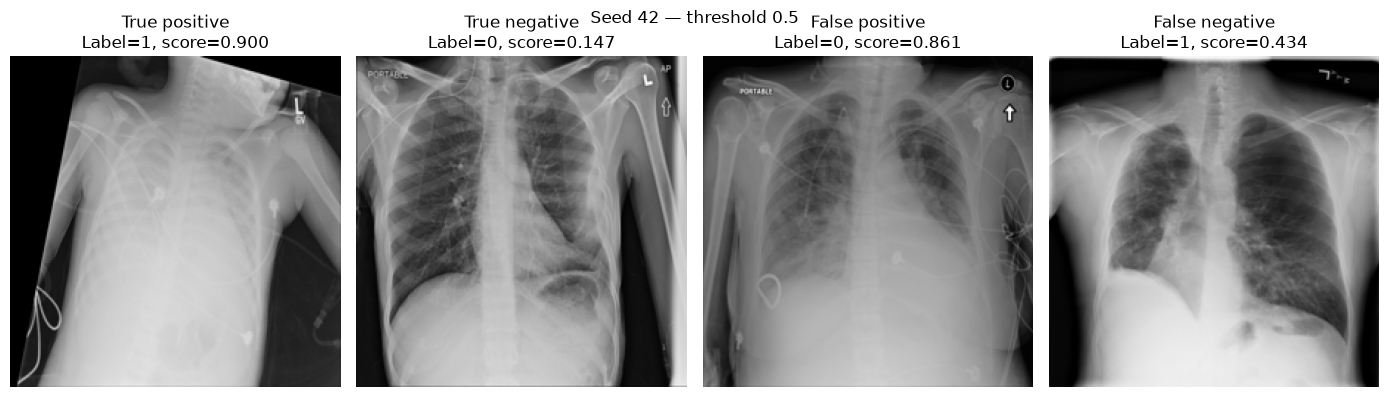

In [85]:
groups = {
    "True positive": (y_test == 1) & test_pred,
    "True negative": (y_test == 0) & ~test_pred,
    "False positive": (y_test == 0) & test_pred,
    "False negative": (y_test == 1) & ~test_pred
}

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, (name, mask) in zip(axes, groups.items()):
    indices = np.flatnonzero(mask)

    if len(indices):
        i = indices[0]
        ax.imshow(images_test[i], cmap="gray", vmin=0, vmax=255)
        ax.set_title(
            f"{name}\nLabel={y_test[i]}, score={test_probs[i]:.3f}"
        )
    else:
        ax.set_title(f"{name}\nNo examples")

    ax.axis("off")

fig.suptitle("Seed 42 — threshold 0.5")
plt.tight_layout()
plt.savefig("outputs/seed42_test_examples.png", dpi=300)
plt.show()

In [86]:
results = []

for view in ["AP", "PA"]:
    mask = test["view"].eq(view).to_numpy()

    labels = y_test[mask]
    probs = test_probs[mask]
    predictions = probs >= threshold

    tn, fp, fn, tp = confusion_matrix(
        labels, predictions, labels=[0, 1]
    ).ravel()

    results.append({
        "view": view,
        "images": len(labels),
        "positives": int(labels.sum()),
        "AUC": roc_auc_score(labels, probs)
            if len(np.unique(labels)) == 2 else np.nan,
        "sensitivity": tp / (tp + fn) if tp + fn else np.nan,
        "specificity": tn / (tn + fp) if tn + fp else np.nan
    })

subgroup_results = pd.DataFrame(results)
print(subgroup_results.round(4))

subgroup_results.to_csv(
    "outputs/seed42_view_subgroups.csv", index=False
)

  view  images  positives     AUC  sensitivity  specificity
0   AP    1361        513  0.8218       0.8947       0.5625
1   PA    1737        172  0.8330       0.4767       0.9176


In [87]:
pred = test_probs >= 0.5
views = test["view"].to_numpy()
import torch.nn.functional as F

groups = {
    "TP": (y_test == 1) & pred,
    "TN": (y_test == 0) & ~pred,
    "AP FP": (y_test == 0) & pred & (views == "AP"),
    "PA FN": (y_test == 1) & ~pred & (views == "PA")
}

selected = {}

for name, mask in groups.items():
    indices = np.flatnonzero(mask)
    if len(indices):
        selected[name] = indices[0]
    else:
        print("No example:", name)

In [88]:
cam_model = make_model()
cam_model.load_state_dict(torch.load(
    "outputs/seed42_stage2_best.pt",
    map_location=device,
    weights_only=True
))
cam_model.eval()

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [89]:
from captum.attr import LayerGradCam, LayerAttribution

cam_model.eval()
cam = LayerGradCam(cam_model, cam_model.layer4)

def grad_cam(image):
    x = torch.tensor(image.copy(), dtype=torch.float32, device=device)
    x = (x / 255)[None, None]
    x.requires_grad_(True)

    heatmap = cam.attribute(x, target=0, relu_attributions=True)
    heatmap = LayerAttribution.interpolate(
        heatmap, image.shape, interpolate_mode="bilinear"
    )[0, 0]

    heatmap = heatmap / heatmap.max().clamp(min=1e-8)
    return heatmap.detach().cpu().numpy()

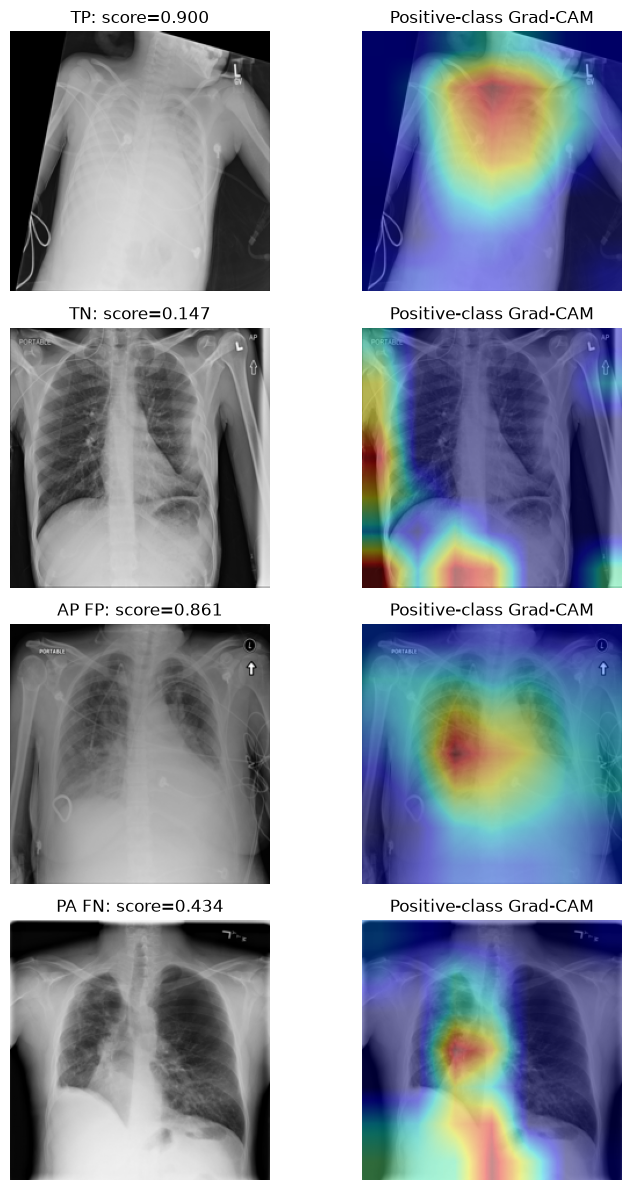

In [90]:
fig, axes = plt.subplots(len(selected), 2, figsize=(8, 12), squeeze=False)
for row, (name, i) in enumerate(selected.items()):
    image = images_test[i]
    heatmap = grad_cam(image)

    for ax in axes[row]:
        ax.imshow(image, cmap="gray", vmin=0, vmax=255)
        ax.axis("off")

    axes[row, 0].set_title(f"{name}: score={test_probs[i]:.3f}")
    axes[row, 1].imshow(heatmap, cmap="jet", alpha=0.4, vmin=0, vmax=1)
    axes[row, 1].set_title("Positive-class Grad-CAM")

plt.tight_layout()
plt.savefig("outputs/seed42_examples_gradcam.png", dpi=300)
plt.show()